In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [7]:
df = pd.read_csv("environments/Data/EMS/CCALAN.csv")

In [9]:
def get_sept_to_jan(df):
    # Convert the date column to datetime
    df = df.copy()
    df['Fecha Hora (YYYY-MM-DD HH:MM)'] = pd.to_datetime(df['Fecha Hora (YYYY-MM-DD HH:MM)'])
    # Extract month
    months = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.month
    # September (9) to January (1), including both
    mask = (months >= 9) | (months <= 1)
    return df[mask]

df_sept_to_jan = get_sept_to_jan(df)

# Enumerate how many seasons are in the data (September to January is one "season" per year)
def get_seasons(df):
    # Group by year, where season is from September (year N) to January (year N+1)
    df = df.copy()
    df['year'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.year
    df['month'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.month
    # For months Sep-Dec, season is the current year; for Jan, season is previous year
    df['season'] = np.where(df['month'] == 1, df['year'] - 1, df['year'])
    seasons = df['season'].unique()
    return np.sort(seasons)

seasons = get_seasons(df_sept_to_jan)
print(f"Number of seasons: {len(seasons)}")
print(f"Seasons: {seasons}")

# Function to select data from a certain season
def select_season(df, season):
    df = df.copy()
    df['year'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.year
    df['month'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.month
    df['season'] = np.where(df['month'] == 1, df['year'] - 1, df['year'])
    return df[df['season'] == season]

# Example usage:
# df_season_2015 = select_season(df_sept_to_jan, 2015)

Number of seasons: 8
Seasons: [2013 2014 2015 2016 2017 2018 2019 2021]


In [10]:
df_season_2015 = select_season(df_sept_to_jan, 2015)

In [11]:
fig = px.line(df_season_2015, x='Fecha Hora (YYYY-MM-DD HH:MM)', y='Radiación Directa Normal (estimado) [mean,W/m2]', title='Radiación Directa Normal (estimado) [mean,W/m2] - Temporada 2015')
fig.show()

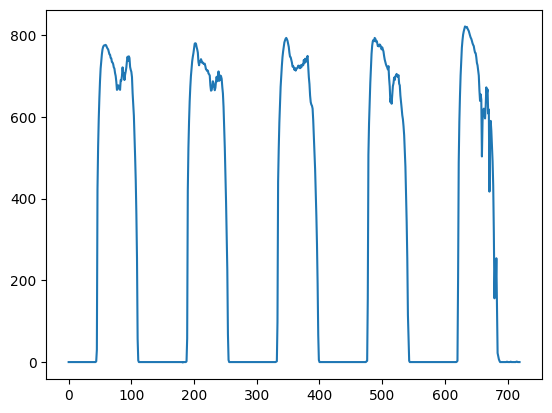

In [17]:
plt.plot(df_season_2015["Radiación Directa Normal (estimado) [mean,W/m2]"].values[0:144*5])

1

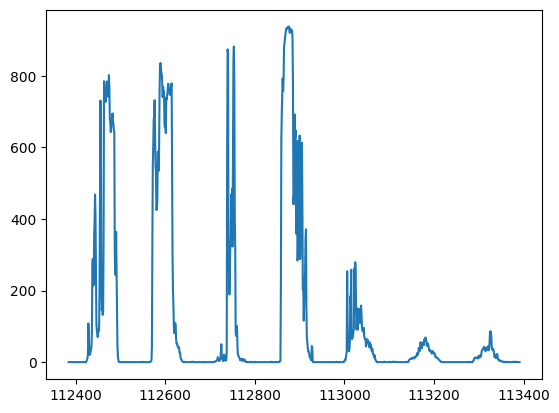

In [38]:
len(plt.plot(df_season_2015["Radiación Directa Normal (estimado) [mean,W/m2]"][144*28:144*5+144*30]))

In [33]:
from environments.utils.funcionesEMS import *

In [22]:
len(df), len(df_sept_to_jan)

(359343, 169014)

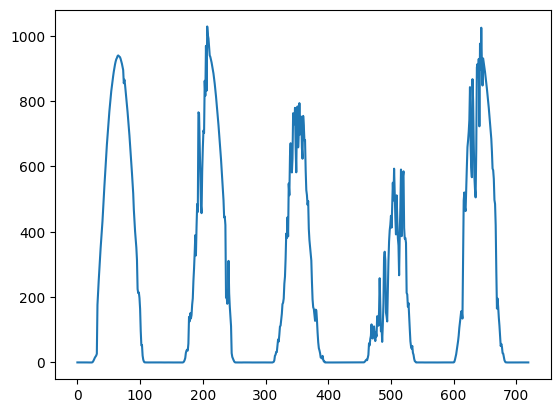

In [36]:
plt.plot(get_rad()[0:144*5])